# Raport: Etap 2 - Dane ustrukturyzowane, eksploracja i analiza (EDA)

## 1. Cel projektu
Celem projektu jest stworzenie i dostrojenie (fine-tuning) modelu językowego LLM zdolnego do automatycznej klasyfikacji postów z serwisu X (dawniej Twitter) pod kątem wykrywania rzeczywistych katastrof. Projekt ma na celu odróżnienie tweetów informujących o prawdziwych zagrożeniach (np. pożary, trzęsienia ziemi) od tych, które używają słów związanych z katastrofami w kontekście metaforycznym.

## 2. Źródło i opis danych
Dane pochodzą z publicznie dostępnego zbioru "Natural Language Processing with Disaster Tweets" z platformy Kaggle. 
Zbiór zawiera ponad 7500 rekordów. Każdy rekord reprezentuje pojedynczy tweet z przypisaną etykietą binarną.

## 3. Cechy i parametry (Opis kolumn)
- `id`: unikalny identyfikator tweeta
- `keyword`: słowo kluczowe z tweeta (może zawierać braki danych - NaN)
- `location`: lokalizacja wysłania tweeta (dużo braków danych)
- `text`: treść tweeta (główne źródło wiedzy dla modelu)
- `target`: etykieta (1 = prawdziwa katastrofa, 0 = brak katastrofy)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud

# Wyłączenie ostrzeżeń dla przejrzystości
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

<div style="page-break-after: always; break-after: page;"></div>

## 4. Wczytanie i przegląd danych
Wczytujemy dane i sprawdzamy ich podstawową strukturę oraz braki.

In [2]:
df = pd.read_csv('../data/train.csv')

display(df.head())
print("\nInformacje o zbiorze:")
df.info()
print("\nBraki danych:")
print(df.isnull().sum())

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1



Informacje o zbiorze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

Braki danych:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


**Analiza + interpretacja:**
Zauważono znaczne braki danych w kolumnach `location` (ponad 2500 braków) oraz `keyword`. Ponieważ w kolejnych etapach projekt opierać się będzie na analizie semantycznej pełnego tekstu (kolumna `text`) z wykorzystaniem modeli LLM, braki w atrybutach pobocznych nie stanowią problemu.

<div style="page-break-after: always; break-after: page;"></div>

## 5. Czyszczenie danych
Treści z mediów społecznościowych są zaszumione. Zanim przeprowadzimy analizę, usuniemy z tekstów adresy URL, wzmianki o użytkownikach (mentions), tagi HTML oraz znaki specjalne.

In [3]:
def clean_tweet(text):
    text = text.lower() # Zmiana na małe litery
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Usuwanie URL
    text = re.sub(r'\@\w+|\#', '', text) # Usuwanie @mentions i znaku #
    text = re.sub(r'<.*?>', '', text) # Usuwanie tagów HTML
    text = re.sub(r'[^a-z0-9\s]', '', text) # Usuwanie znaków specjalnych
    text = text.replace('\n', ' ').strip()
    return text

# Aplikacja funkcji na kolumnie text
df['clean_text'] = df['text'].apply(clean_tweet)

## 6. Eksploracyjna Analiza Danych (EDA)

### 6.1. Rozkład klas (Target distribution)
Sprawdźmy, czy zbiór danych jest zbalansowany.

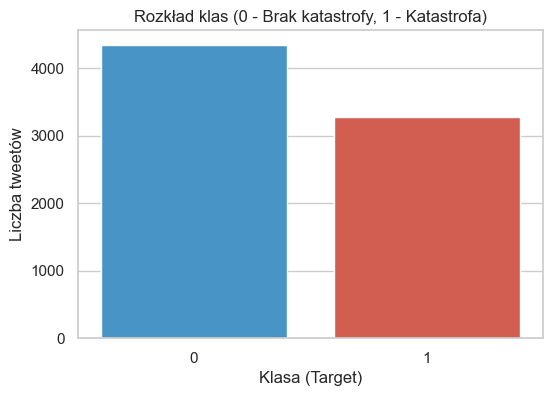

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='target', palette=['#3498db', '#e74c3c'])
plt.title('Rozkład klas (0 - Brak katastrofy, 1 - Katastrofa)')
plt.xlabel('Klasa (Target)')
plt.ylabel('Liczba tweetów')
plt.show()

**Analiza + interpretacja:**
Wykres pokazuje, że klasy są stosunkowo dobrze zbalansowane (ok. 4300 tweetów negatywnych i 3200 pozytywnych). Lekki brak balansu jest akceptowalny w kontekście uczenia maszynowego i nie wymaga stosowania technik oversamplingu. Będziemy mogli opierać się na metryce standardowej dokładności (Accuracy) w kolejnych etapach.

### 6.2. Analiza długości tekstów
Czy tweety opisujące rzeczywiste zagrożenia różnią się długością od zwykłych tweetów?

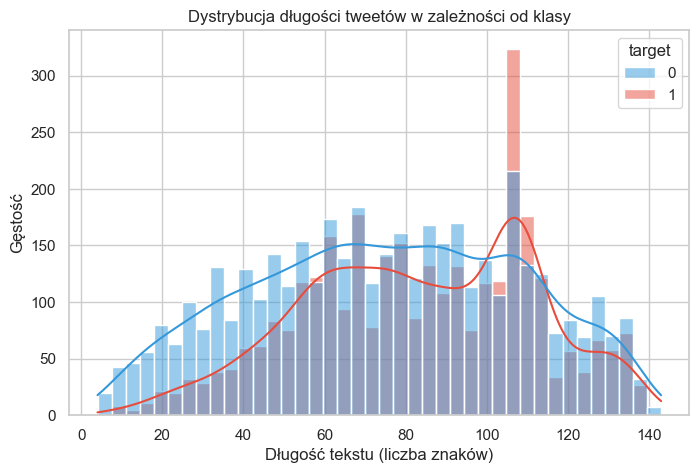

In [5]:
df['text_length'] = df['clean_text'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='text_length', hue='target', bins=40, kde=True, palette=['#3498db', '#e74c3c'])
plt.title('Dystrybucja długości tweetów w zależności od klasy')
plt.xlabel('Długość tekstu (liczba znaków)')
plt.ylabel('Gęstość')
plt.show()

**Analiza + interpretacja:**
Rozkład długości tekstów wskazuje, że tweety oznaczające faktyczne katastrofy (target=1) mają tendencję do bycia nieco dłuższymi (szczyt dystrybucji przesuwa się w prawo). Wynika to prawdopodobnie z faktu, że osoby raportujące zagrożenie starają się przekazać więcej szczegółowych informacji i faktów, podczas gdy tweety metaforyczne są często krótsze.

<div style="page-break-after: always; break-after: page;"></div>

### 6.3. Chmura słów (WordCloud)
Jakie słowa występują najczęściej w tweetach sklasyfikowanych jako prawdziwe zagrożenie?

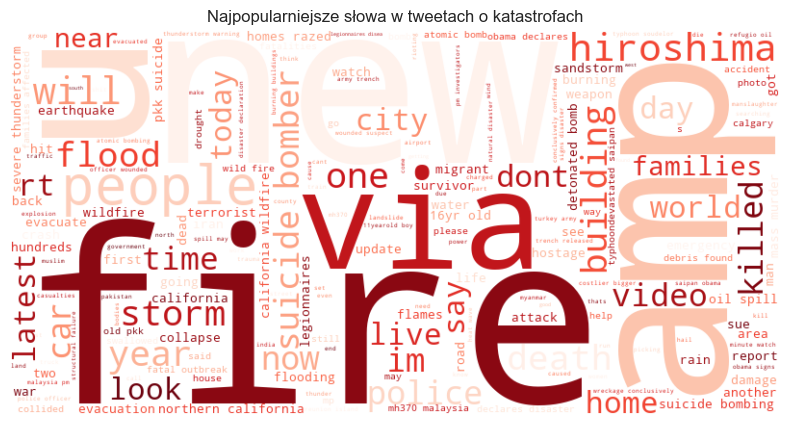

In [6]:
disaster_tweets = " ".join(df[df['target'] == 1]['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(disaster_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Najpopularniejsze słowa w tweetach o katastrofach')

plt.savefig('../outputs/plot1.png', bbox_inches='tight')
plt.show()

**Analiza + interpretacja:**
Chmura słów wyraźnie odzwierciedla tematykę katastrof i zagrożeń. Najczęściej występujące słowa bezpośrednio wskazujące na niebezpieczne sytuacje i ich ofiary.  
W korpusie dominują terminy związane z:

Klęskami żywiołowymi: "flood" (powódź), "storm" (burza), "wildfire" (pożar lasu), "sandstorm" (burza piaskowa)  
Wypadkami i atakami: "accident" (wypadek), "crash" (katastrofa), "attack" (atak), "suicide bomber" (zamachowiec samobójca), "terrorist" (terrorysta)  
Konsekwencjami: "burning" (płonący), "damage" (zniszczenia), "evacuate" (ewakuacja), "emergency" (sytuacja awaryjna), "debris" (gruzy)

Słowa takie jak "families", "homes", "survivor" podkreślają ludzki wymiar tragedii. Obecność konkretnych lokalizacji ("hiroshima", "calgary", "iran") oraz słów "latest", "today", "world" sugeruje, że tweety o katastrofach odnoszą się do rzeczywistych, bieżących wydarzeń o zasięgu globalnym.

Jakie słowa występują najczęściej w zwykłych tweetach?

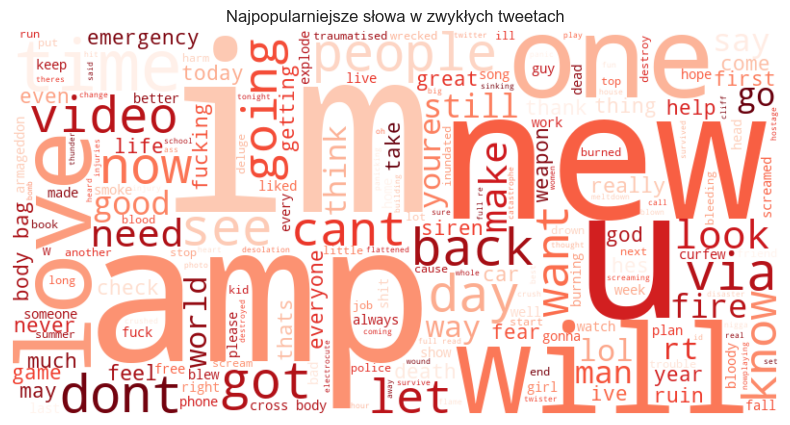

In [7]:
not_disaster_tweets = " ".join(df[df['target'] == 0]['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(not_disaster_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Najpopularniejsze słowa w zwykłych tweetach')

plt.savefig('../outputs/plot2.png', bbox_inches='tight')
plt.show()

**Analiza + interpretacja:**
Chmura słów dla zwykłych tweetów ma zupełnie odmienny charakter – dominują tu słowa konwersacyjne i codzienne.

Charakterystyczne elementy:

Czasowniki modalne i pomocnicze: "can't", "don't", "will" – typowe dla wyrażania opinii i emocji  
Słowa związane z komunikacją: "say", "think", "feel", "look", "video"  
Kolokwializmy: "youre", "fuck", "lol", "shit" – wskazujące na nieformalny ton  
Codzienne aktywności: "day", "make", "go", "want", "help", "work"  

W przeciwieństwie do tweetów o katastrofach, tutaj brakuje konkretnych nazw miejsc czy wydarzeń. Słowa są bardziej abstrakcyjne i emocjonalne ("feel", "like", "bad"), co sugeruje, że zwykłe tweety to przede wszystkim osobiste opinie, żarty, codzienne obserwacje i rozmowy, a nie relacje z rzeczywistych zdarzeń.

In [8]:
# Zapisanie wyczyszczonego zbioru danych do folderu outputs
clean_df = df[['id', 'clean_text', 'target', 'text_length']]
clean_df.to_csv('../outputs/train_cleaned.csv', index=False)
print("Dane zostały wyczyszczone i zapisane do outputs/train_cleaned.csv")

Dane zostały wyczyszczone i zapisane do outputs/train_cleaned.csv


## 7. Podział pracy / wkład członków grupy

Projekt realizowany w trzyosobowej grupie, z częściowo wspólnym wkładem w poszczególne etapy prac.

- Edgar Lis – głównie odpowiedzialny za analizę problemu, wybór źródła danych oraz określenie celu projektu; wspierał również wstępną eksplorację danych.
- Vladyslav Kyzylov – głównie odpowiedzialny za implementację rozwiązania (kodowanie), przygotowanie i rozwój struktury projektu; uczestniczył także w analizie danych.
- Maciej Rożek – głównie odpowiedzialny za opracowanie dokumentacji oraz przygotowanie raportu końcowego; wspierał również organizację projektu i weryfikację wyników.

Wszyscy członkowie zespołu brali udział w konsultacjach dotyczących kierunku projektu oraz końcowej weryfikacji rezultatów.